# Imports

In [110]:
%cd ~/Code/naam

import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
from naam import models
import torch



%load_ext autoreload
%autoreload 2

np.random.seed(42)
    
# Step 1: Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")  # Use the first CUDA device
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")  # Fallback to CPU if GPU is not available
    print("GPU is not available, using CPU instead.")



def convert_bit_vector_to_torch(bit_vector):
    tmp = 2*torch.tensor(bit_vector, dtype = float) - 1
    tmp = tmp.flatten().unsqueeze(1)
    return  tmp
    

def audio_to_quantized_spectrogram(audio_path, sr=16000, n_mels=64, n_fft=512, hop_length=256, bits=4,length = None):
    """Convert audio to a quantized mel spectrogram."""
    # Load audio
    y, sr = librosa.load(audio_path, sr=sr)

    if length != None:
        y = y[:length]

    # Convert to mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)

    # Normalize between 0 and 1
    S_min, S_max = S_db.min(), S_db.max()
    S_norm = (S_db - S_min) / (S_max - S_min)

    # Quantize to discrete levels (2^bits)
    num_levels = 2 ** bits
    S_quantized = np.round(S_norm * (num_levels - 1)).astype(np.uint8)

    return y, S,S_quantized, S_min, S_max, sr, hop_length

def quantized_spectrogram_to_audio(S_quantized, S_min, S_max, sr, hop_length, bits=4, seed=42):
    """
    Reconstruct audio from a quantized mel spectrogram by:
    1) Converting the quantized mel spectrogram to linear-frequency STFT magnitudes
    2) Applying the Griffin-Lim algorithm for phase reconstruction directly

    Parameters
    ----------
    S_quantized : np.ndarray
        Quantized Mel spectrogram (integer-coded).
    S_min : float
        Minimum dB level used during quantization.
    S_max : float
        Maximum dB level used during quantization.
    sr : int
        Sample rate.
    hop_length : int
        Hop length for STFT.
    bits : int, optional
        Number of bits used for quantization (default=4).
    seed : int or None, optional
        Fixed random seed for reproducible Griffin-Lim phase initialization.
        If None, Griffin-Lim will use a random seed each time (non-deterministic).

    Returns
    -------
    y_reconstructed : np.ndarray
        Time-domain waveform reconstructed from the quantized mel spectrogram.
    """

    # Fix random seed if provided (helps make Griffin-Lim deterministic if init='random')
    if seed is not None:
        np.random.seed(seed)

    # Number of quantization levels
    num_levels = 2 ** bits

    # Convert integer-coded values [0, num_levels-1] to [0, 1]
    S_norm = S_quantized.astype(np.float32) / (num_levels - 1)

    # Scale it back to original dB range [S_min, S_max]
    S_db = S_norm * (S_max - S_min) + S_min

    # Convert dB mel-spectrogram to power mel-spectrogram
    S_mel = librosa.db_to_power(S_db)

    # Convert the mel spectrogram to STFT magnitudes
    # (this does NOT do phase reconstruction, just amplitude conversion)
    stft_magnitudes = librosa.feature.inverse.mel_to_stft(
        S_mel,
        sr=sr,
        n_fft=512
        # add more params if needed, e.g. fmin, fmax, etc.
    )

    # Now apply Griffin-Lim to get time-domain signal
    # If your version of librosa supports it, you can try init=None or init='random', 
    # and/or random_state=some_int. Otherwise, you rely on the global seed above.
    y_reconstructed = librosa.griffinlim(
        stft_magnitudes,
        n_iter=32,
        hop_length=hop_length,
        n_fft=512,    # Sometimes you may want to specify n_fft explicitly
        init='random',  # If supported by your librosa version
        random_state=0  # If supported by your librosa version
    )

    return y_reconstructed

def plot_spectrograms(S_original, S_quantized, sr, hop_length):
    """Plots the original and quantized mel spectrograms side by side."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Plot the original spectrogram
    img1 = librosa.display.specshow(S_original, sr=sr, hop_length=hop_length, cmap="magma", ax=ax[0])
    ax[0].set_title("Original Mel Spectrogram")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Mel Frequency Bin")
    fig.colorbar(img1, ax=ax[0])

    # Plot the quantized spectrogram
    img2 = librosa.display.specshow(S_quantized, sr=sr, hop_length=hop_length, cmap="magma", ax=ax[1])
    ax[1].set_title("Quantized Mel Spectrogram")
    ax[1].set_xlabel("Time")
    ax[1].set_ylabel("Mel Frequency Bin")
    fig.colorbar(img2, ax=ax[1])

    plt.tight_layout()
    plt.show()


def quantized_to_bit_vector(S_quantized, bits=4):
    """Convert quantized spectrogram to a bit vector."""
    # Flatten the matrix
    flat_values = S_quantized.flatten()

    # Convert each integer value to a binary string with a fixed length (e.g., 4 bits)
    bit_strings = [format(v, f'0{bits}b') for v in flat_values]

    # Concatenate all binary strings into one long bit vector
    bit_vector = ''.join(bit_strings)

    # Convert to a numpy array of 0s and 1s
    bit_array = np.array([int(b) for b in bit_vector], dtype=np.uint8)

    return bit_array


def bit_vector_to_quantized(bit_array, shape, bits=4):
    """Convert a bit vector back to a quantized spectrogram matrix."""
    # Convert bit array back to a long binary string
    bit_string = ''.join(map(str, bit_array))

    # Break into chunks of `bits` length and convert back to integers
    int_values = np.array([int(bit_string[i:i+bits], 2) for i in range(0, len(bit_string), bits)], dtype=np.uint8)

    # Reshape to the original spectrogram shape
    S_reconstructed = int_values.reshape(shape)

    return S_reconstructed


def flip_bits(bit_vector, p=0.01):
    """Randomly flips bits in the bit vector with probability p."""
    # Generate a mask where each bit flips with probability p
    flip_mask = np.random.rand(len(bit_vector)) < p

    # XOR the bit vector with the mask (1 XOR 1 = 0, 0 XOR 1 = 1, so it flips)
    flipped_bit_vector = np.bitwise_xor(bit_vector, flip_mask.astype(np.uint8))

    return flipped_bit_vector

def plot_bit_vector_as_image(bit_vector):
    """Reshapes bit_vector into the largest possible square and plots it."""

    # Compute the largest possible square size
    length = len(bit_vector)
    size = int(np.floor(np.sqrt(length)))  # Largest integer square root

    # Trim bit_vector to fit exactly into a square
    bit_vector_trimmed = bit_vector[:size * size]

    # Reshape into a 2D array
    bit_matrix = bit_vector_trimmed.reshape((size, size))

    # Plot using imshow
    plt.figure(figsize=(6, 6))
    plt.imshow(bit_matrix, cmap='gray', interpolation='nearest')
    plt.colorbar(label="Bit Value (0 or 1)")
    plt.title("Bit Vector Representation")
    plt.axis("off")  # Hide axis for cleaner visualization
    plt.show()

def ensure_same_size(bit_vector1, bit_vector2):
    """Ensures two bit vectors have the same size by trimming or padding."""
    min_length = min(len(bit_vector1), len(bit_vector2))
    
    # Trim both to the same size
    bit_vector1 = bit_vector1[:min_length]
    bit_vector2 = bit_vector2[:min_length]

    return bit_vector1, bit_vector2

/u/leokoz8/Code/naam
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using GPU: Tesla V100-SXM2-32GB


# Load spectrogram and plot quantized

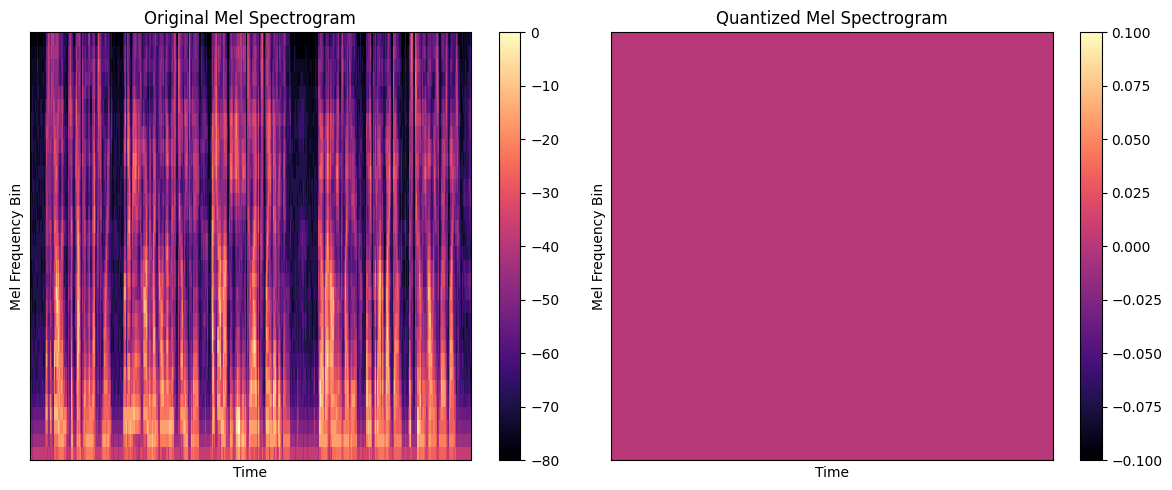

In [53]:
# Load an example file from librosa
audio_path = librosa.example('libri3')  # Returns a valid path

# Convert to quantized spectrogram
y_original, S,S_quantized, S_min, S_max, sr, hop_length = audio_to_quantized_spectrogram(audio_path,n_mels = 32,hop_length = 512)

# Reconstruct audio
y_reconstructed = quantized_spectrogram_to_audio(S_quantized, S_min, S_max, sr, hop_length,bits = 4)

# Convert spectrogram back to dB for visualization
S_original_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y_reconstructed, sr=sr, n_fft=512, hop_length=hop_length, n_mels=S_quantized.shape[0]), ref=np.max)
S_quantized_db = (S_quantized / S_quantized.max()) * S_original_db.max()  # Normalize for visualization

# Display side-by-side
plot_spectrograms(S_original_db, S_quantized_db, sr, hop_length)


# Noisy bit-level representation of spectrogram

In [13]:
# Convert S_quantized to bit vector
bit_vector = quantized_to_bit_vector(S_quantized, bits=4)

# Example usage:
p = 0.40  # Probability of flipping each bit
bit_vector_flipped = flip_bits(bit_vector, p)






# # Reconstruct S_quantized
# S_reconstructed = bit_vector_to_quantized(bit_vector_flipped, S_quantized.shape, bits=4)
# librosa.display.specshow(S_reconstructed, sr=sr, hop_length=hop_length, cmap="magma")

# # Call the function to plot
# plot_bit_vector_as_image(bit_vector_flipped)

# Storing and retrieving memories in a Hopfield network

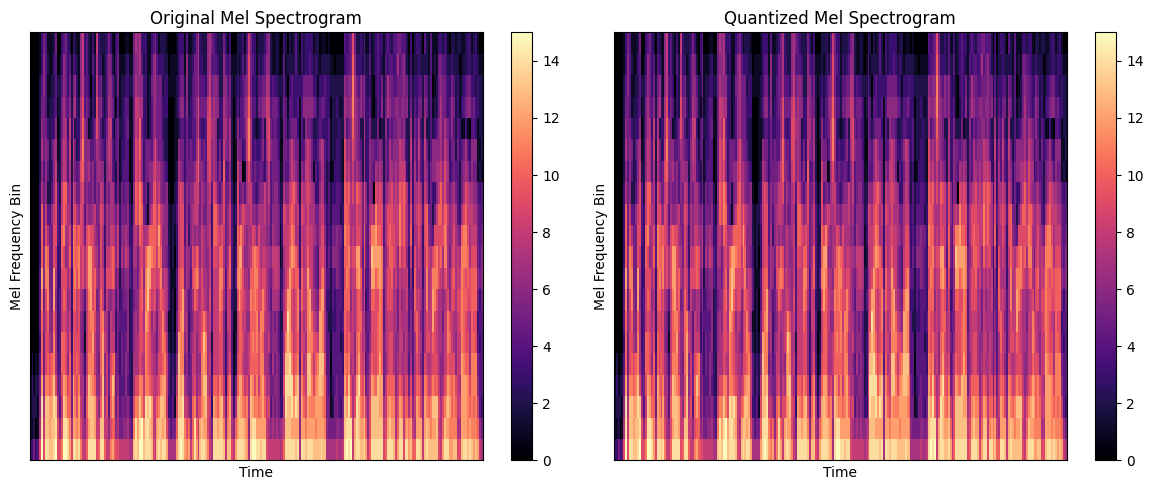

In [55]:
# Load an example file from librosa
audio_path_1 = librosa.example('libri1')  # Returns a valid path
audio_path_2 = librosa.example('libri2')  # Returns a valid path

# Convert to quantized spectrogram
y_1,_,S_quantized_1, S_min_1, S_max_1, sr_1, hop_length_1 = audio_to_quantized_spectrogram(audio_path_1, n_mels = 20, hop_length = 512*2)
y_2, _,S_quantized_2, S_min_2, S_max_2, sr_2, hop_length_2 = audio_to_quantized_spectrogram(audio_path_2, n_mels = 20, hop_length = 512*2)

def trim_S_quantized(S_quantized_1,S_quantized_2):
    min_length = min(S_quantized_1.shape[1],S_quantized_2.shape[1])
    
    return S_quantized_1[:,:min_length], S_quantized_2[:,:min_length]

S_quantized_1_trimmed,S_quantized_2_trimmed = trim_S_quantized(S_quantized_1,S_quantized_2)


bit_vector_1 = quantized_to_bit_vector(S_quantized_1_trimmed, bits=4)
bit_vector_2 = quantized_to_bit_vector(S_quantized_2_trimmed, bits=4)

plot_spectrograms(S_quantized_1_trimmed,S_quantized_1_trimmed,sr = sr_1, hop_length = hop_length_1)

In [36]:
bit_vector_1_torch = convert_bit_vector_to_torch(bit_vector_1)
bit_vector_2_torch = convert_bit_vector_to_torch(bit_vector_2)

etas = torch.concatenate((bit_vector_1_torch,bit_vector_2_torch),1).to(device)

print("Storing and retriving memories...")
x, S, P, initial_distance, final_distance,x0 = models.integrate_dynamics(N=etas.shape[0], K = etas.shape[1], NUM_STEPS=int(1e3), dt=0.05, beta=5, corruption_level=0.2, 
                        etas=etas, memory_to_seed_from=0, device=device)

Storing and retriving memories...


100%|███████████████████████████████████████| 1000/1000 [02:51<00:00,  5.85it/s]


Initial L2 distance of neural state to memory 0 is 121.72099243762351
Final L2 distance of neural state to memory 0 is 0.0


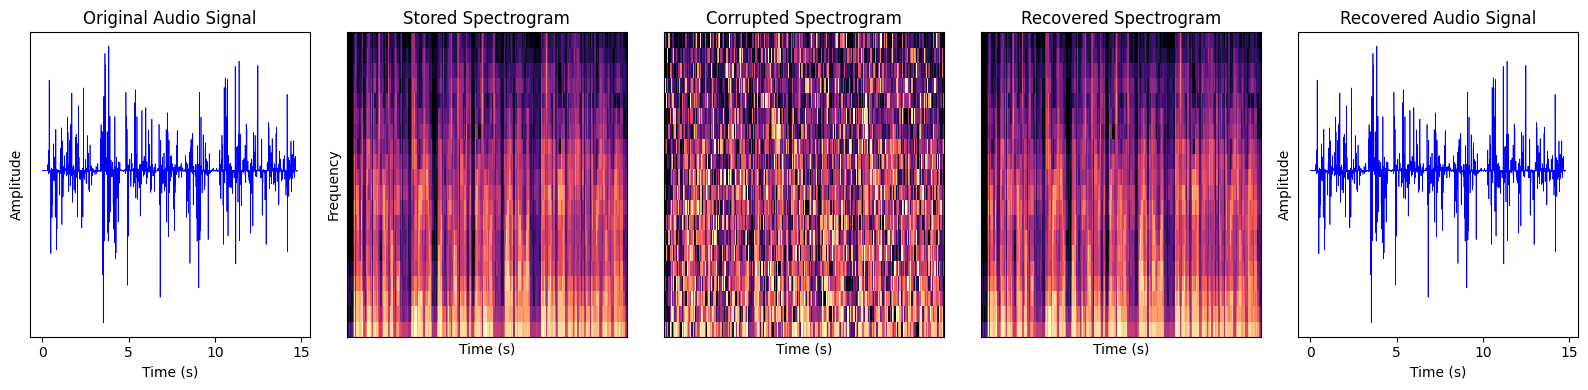

In [158]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

def convert_hopfield_output_to_S(x):
    tmp = (torch.sign(x) + 1) / 2  # Converts -1 to 0, +1 to 1
    tmp = tmp.detach().cpu().numpy().astype(np.uint8)  # Convert to uint8
    return tmp

# Assuming you already have these variables defined:
#  x0, x, S_quantized_1_trimmed, S_min_1, S_max_1, sr_1, hop_length_1

S_reconstructed_corrupted_input_hopfield = bit_vector_to_quantized(
    convert_hopfield_output_to_S(x0), S_quantized_1_trimmed.shape, bits=4
)
S_reconstructed_hopfield = bit_vector_to_quantized(
    convert_hopfield_output_to_S(x), S_quantized_1_trimmed.shape, bits=4
)

y_reconstructed_original = quantized_spectrogram_to_audio(
    S_quantized_1_trimmed, S_min_1, S_max_1, sr_1, hop_length_1, bits=4
)
y_reconstructed_hopfield = quantized_spectrogram_to_audio(
    S_reconstructed_hopfield, S_min_1, S_max_1, sr_1, hop_length_1, bits=4
)

# Create time arrays for the raw/reconstructed audio signals
time_original = np.linspace(
    0, len(y_reconstructed_original) / sr_1, num=len(y_reconstructed_original)
)
time_recovered = np.linspace(
    0, len(y_reconstructed_hopfield) / sr_1, num=len(y_reconstructed_hopfield)
)

# Define figure and axes
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

# --- Plot 1: Original audio signal ---
axes[0].plot(time_original, y_reconstructed_original, linewidth=0.5, color='b')
axes[0].set_title("Original Audio Signal")
axes[0].set_xlabel("Time (s)")
# Remove y-axis ticks and label
axes[0].set_ylabel("Amplitude")
axes[0].set_yticks([])
axes[0].grid(False)

# --- Plot 2: Stored spectrogram ---
librosa.display.specshow(
    S_quantized_1_trimmed, sr=sr_1, hop_length=hop_length_1,
    cmap="magma", ax=axes[1]
)
axes[1].set_title('Stored Spectrogram')
axes[1].set_xlabel("Time (s)")
# Remove y-axis ticks and label
axes[1].set_ylabel("Frequency")
axes[1].set_yticks([])

# --- Plot 3: Corrupted spectrogram ---
librosa.display.specshow(
    S_reconstructed_corrupted_input_hopfield, sr=sr_1, hop_length=hop_length_1,
    cmap="magma", ax=axes[2]
)
axes[2].set_title('Corrupted Spectrogram')
axes[2].set_xlabel("Time (s)")
# Remove y-axis ticks and label
axes[2].set_ylabel("")
axes[2].set_yticks([])

# --- Plot 4: Recovered spectrogram ---
librosa.display.specshow(
    S_reconstructed_hopfield, sr=sr_1, hop_length=hop_length_1,
    cmap="magma", ax=axes[3]
)
axes[3].set_title('Recovered Spectrogram')
axes[3].set_xlabel("Time (s)")
# Remove y-axis ticks and label
axes[3].set_ylabel("")
axes[3].set_yticks([])

# --- Plot 5: Recovered audio signal ---
axes[4].plot(time_recovered, y_reconstructed_hopfield, linewidth=0.5, color='b')
axes[4].set_title("Recovered Audio Signal")
axes[4].set_xlabel("Time (s)")
axes[4].grid(False)
# Remove y-axis ticks and label
axes[4].set_ylabel("Amplitude")
axes[4].set_yticks([])

plt.tight_layout()
plt.savefig('reconstructed_speech_data.pdf',dpi = 300)
plt.show()




16000